In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_multiple_scans

# import scanning points
import pickle

df_points = {}

with open('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor_fine.pickle', 'rb') as f:
    x = pickle.load(f)

# Create DataFrame
df_points["fine"] = pd.DataFrame({
    'astro_nue_ratio': x["astro_nue_ratio"],
    'astro_nutau_ratio': x["astro_nutau_ratio"],
    'fe': x["astro_nue_ratio"]/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
    'fmu': 1/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
    'ftau': x["astro_nutau_ratio"]/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
})

with open('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor_fine_center.pickle', 'rb') as f:
    x = pickle.load(f)

# Create DataFrame
df_points["center"] = pd.DataFrame({
    'astro_nue_ratio': x["astro_nue_ratio"],
    'astro_nutau_ratio': x["astro_nutau_ratio"],
    'fe': x["astro_nue_ratio"]/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
    'fmu': 1/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
    'ftau': x["astro_nutau_ratio"]/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
})

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

# dict with all my dag scans
from scan_dict import scan_dir_dict

In [3]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/debug_minimizer/systematics"
os.system(f"mkdir -p {plotting_path}")

0

In [ ]:
def study_contour( scan_dirs, drop_unsuccessful = False, N_grid = 20, levels = ['68%','90%'],plot_points = None,ts_cut = None ):

    scan_dict = {}
    data = {}

    for i, scan_dir in enumerate(scan_dirs):
        name = i
        data[name] = {}
        scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid = N_grid)

    # Apply ts_cut: remove points where ts > ts_cut
    if ts_cut is not None:
        for key in data:
            mask = np.array(data[key]["ts"]) <= ts_cut
            data[key]["ftau"] = np.array(data[key]["ftau"])[mask]
            data[key]["fe"]   = np.array(data[key]["fe"])[mask]
            data[key]["ts"]   = np.array(data[key]["ts"])[mask]

    if len(scan_dirs) > 1:
        name = "combined"
        data[name] = {}
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points_multiple_scans(scan_dict,scan_dict.keys(), N_grid = N_grid)

    # Create a 2D histogram for the heatmap
    heatmap, xedges, yedges = np.histogram2d( data[name]["ftau"], data[name]["fe"], bins=50, range=[[0, 1], [0, 1]])

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    if plot_points:
        ax.scatter( df_points[plot_points]["ftau"],df_points[plot_points]["fe"], color = "red" )

    # sc = ax.scatter(df["ftau"],df["fe"],c=df["dllh"],cmap="coolwarm",alpha=0.6,edgecolors="none",s=25)
    sc = ax.scatter(data[name]["ftau"],data[name]["fe"],c=data[name]["ts"],cmap="coolwarm",alpha=0.6,edgecolors="none",s=25)
    
    ts_dict = {'68%' : 2.37,'90%' : 4.605,'95%' : 5.99}

    ts_values = [ts_dict[i] for i in levels]

    C2 = ax.contour(data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"],  ts_values,linestyles=["-",'--'],linewidths=3,colors='black')

    # Annotate each point with its dllh value
    for i in range(len(data[name]["ftau"])):
        ax.annotate(
            f"{data[name]['ts'][i]:.2f}",  # Format dllh to 2 decimal places
            (data[name]["ftau"][i], data[name]["fe"][i]),
            fontsize=8,
            textcoords="offset points",
            xytext=(2, 3),  # Offset the text slightly from the point
            ha='left'
        )

    fig.colorbar(sc, ax=ax, label="dllh")

    # Add labels and title
    ax.set_title("2D Heatmap of fe vs. fmu with dllh as Color")
    ax.set_xlabel("ftau")
    ax.set_ylabel("fe")
    ax.grid(True)

    plt.show()

    dfs = {}

    for key in data:
        dfs[key] = pd.DataFrame({
            "ftau": data[key]["ftau"],
            "fe": data[key]["fe"],
            "ts": data[key]["ts"]
        })

    return dfs, scan_dict


I created my own minimizer function, looks quite a bit better

removed stuff


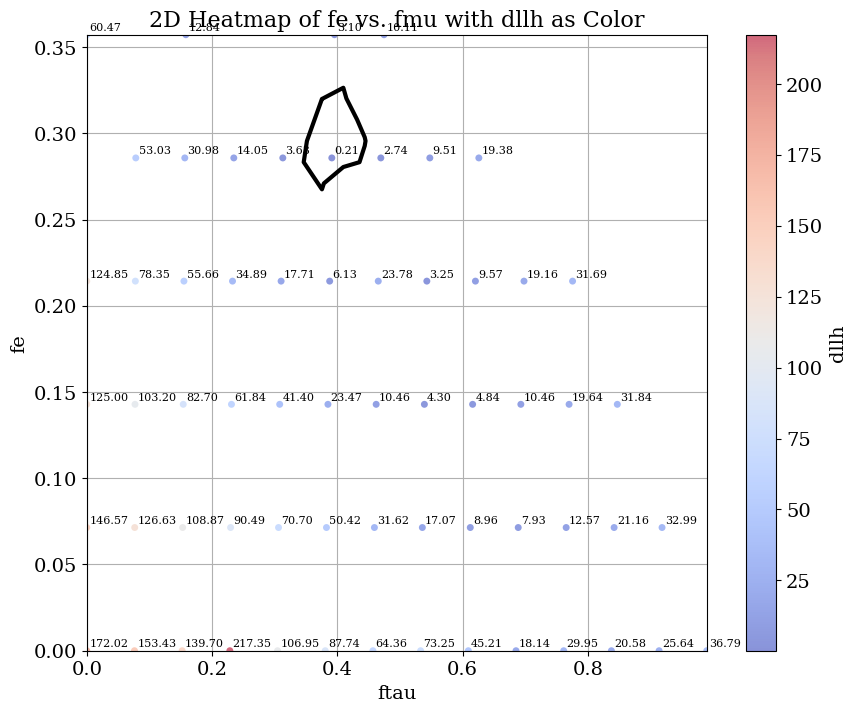

In [ ]:
# datasets v3 globalfit_hese

# spl
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v3/SAY/globalfit_double_no_hybrid_hese_SPL_noinel_nosyst"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v3/SAY/globalfit_double_no_hybrid_hese_SPL_nosyst"

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v3/SAY/globalfit_double_no_hybrid_hese_BPL_noinel_nosyst" # 1 small wonk
# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v3/SAY/globalfit_double_no_hybrid_hese_BPL_noinel_nosyst_minimizer_hybrid_nlight_20" # failed freefit

# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v3/SAY/globalfit_double_no_hybrid_hese_SPL_noinel"
# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v3/SAY/globalfit_double_no_hybrid_hese_BPL_noinel" # still running


dfs, scan_dict = study_contour( scan_dirs = [scan_dir], drop_unsuccessful=True, N_grid = 30, levels = ["68%"], plot_points=None, ts_cut=None )


removed stuff


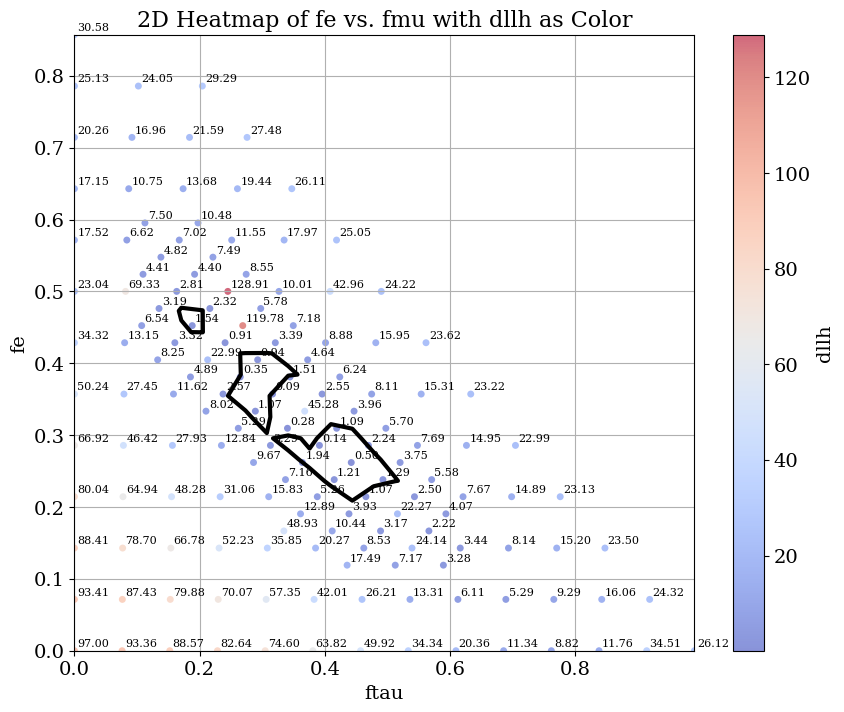

In [12]:
# datasets v3 globalfit

# spl
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v3/SAY/globalfit_double_no_hybrid_SPL_nosyst"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v3/SAY/globalfit_double_no_hybrid_nohese_SPL_nosyst"

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v3/SAY/globalfit_double_no_hybrid_SPL"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v3/SAY/globalfit_double_no_hybrid_nohese_SPL"

# bpl
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v3/SAY/globalfit_double_no_hybrid_BPL_noinel_nosyst" # one failed point
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v3/SAY/globalfit_double_no_hybrid_BPL_noinel_nosyst_minimizer_hybrid_nlight_20" # another failed point

# dfs, scan_dict = study_contour( scan_dirs = ["/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v3/SAY/globalfit_double_no_hybrid_BPL_noinel_nosyst",
#                                              "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v3/SAY/globalfit_double_no_hybrid_BPL_noinel_nosyst_minimizer_hybrid_nlight_20"], 
#                                              drop_unsuccessful=True, N_grid = 30, levels = ["68%"], plot_points=None, ts_cut=None ) # perfect!


scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v3/SAY/globalfit_double_no_hybrid_BPL_noinel" # still running

dfs, scan_dict = study_contour( scan_dirs = [scan_dir], drop_unsuccessful=True, N_grid = 30, levels = ["68%"], plot_points=None, ts_cut=None )


removed stuff


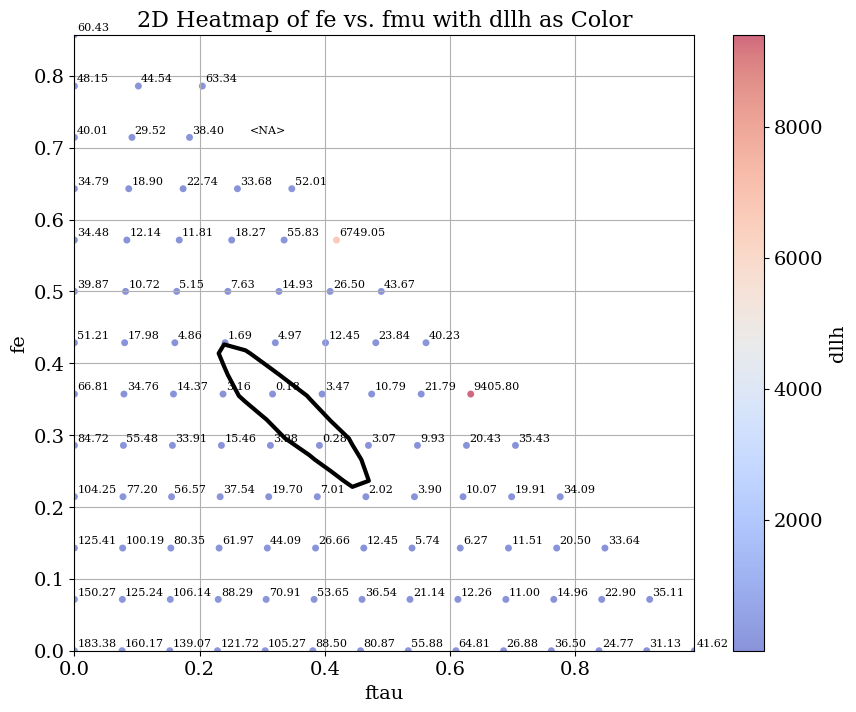

In [ ]:
# scan_dirs = ["/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_HESEBestfit_SPL_noinel_hybrid_minimizer",
#             "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_HESEBestfit_SPL_noinel"]

# df = study_contour( scan_dirs = scan_dirs, drop_unsuccessful=True, N_grid = 50, levels = ['68%','90%'], plot_points="center" )

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_SPL_noinel_hybrid_minimizer"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_BPL_noinel_hybrid_minimizer"

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_SPL_noinel_hybrid_minimizer_fine"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_HESEBestfit_SPL_noinel_hybrid_minimizer_fine"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_BPL_noinel_hybrid_minimizer_fine"

# new minimizer with HESE and systematics
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_HESEBestfit_SPL_noinel_hybrid_minimizer_nlight_20_fine"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_HESEBestfit_SPL_noinel_force_minimizer_full_2_fine"

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_HESEBestfit_SPL_noinel_force_minimizer_full_3_nlight_20_fine"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_SPL_noinel_force_minimizer_full_3_nlight_20_fine"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/second_minimizer/hese_BPL_noinel_force_minimizer_full_3_nlight_20_fine"

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/third_benchmark/SAY/hese_HESEBestfit_SPL_noinel"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/third_benchmark/SAY/hese_SPL_noinel"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/third_benchmark/SAY/hese_BPL_noinel"

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/third_benchmark/SAY/hese_HESEBestfit_SPL"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/third_benchmark/SAY/hese_SPL"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/third_benchmark/SAY/hese_BPL"

# globalfit SPL
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/Poisson/globalfit_double_no_hybrid_SPL_nosyst"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/Poisson/globalfit_double_no_hybrid_nohese_SPL_nosyst"

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/Poisson/globalfit_double_no_hybrid_SPL"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/Poisson/globalfit_double_no_hybrid_nohese_SPL"

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_SPL"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_nohese_SPL"


# globalfit BPL
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v1/Poisson/globalfit_double_no_hybrid_BPL_nosyst"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/Poisson/globalfit_double_no_hybrid_BPL_noinel_nosyst_failed"
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/Poisson/globalfit_double_no_hybrid_BPL_noinel_nosyst"

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_BPL_noinel_nosyst" # failed
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_nohese_BPL_noinel_nosyst" # failed

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_BPL_nosyst" # failed
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_nohese_BPL_nosyst" # failed

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_BPL_noinel_nosyst_minimizer_hybrid" 
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_BPL_noinel_nosyst_minimizer_hybrid_nlight_20" 

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_BPL_nosyst_minimizer_hybrid"  # failed
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_nohese_BPL_nosyst_minimizer_hybrid" # failed

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_BPL_nosyst_minimizer_hybrid_nlight_20" # still failed
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_nohese_BPL_nosyst_minimizer_hybrid_nlight_20" # still failed

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_BPL_noinel_minimizer_hybrid"  # looks slightly bad
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_nohese_BPL_noinel_minimizer_hybrid" # looks bad

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_BPL_noinel_minimizer_hybrid_nlight_20"  # good enough!
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_nohese_BPL_noinel_minimizer_hybrid_nlight_20" # looks bad

scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_BPL_minimizer_hybrid"  # failed
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_nohese_BPL_minimizer_hybrid" # failed

# # globalfit hese
# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/Poisson/globalfit_double_no_hybrid_hese_SPL_noinel_nosyst"

# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_SPL_noinel_nosyst"
# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_BPL_noinel_nosyst" # failed

# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_SPL_nosyst"
# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_BPL_nosyst" # failed

# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_BPL_noinel_nosyst_minimizer_hybrid" # bingo
# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_BPL_noinel_nosyst_minimizer_hybrid_nlight_20" # bingo

# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_BPL_noinel_minimizer_hybrid" # failed
# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_BPL_noinel_minimizer_hybrid_nlight_20" # bingo, couple not finished because too long but looks fine

# scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_SPL_noinel"

dfs, scan_dict = study_contour( scan_dirs = [scan_dir], drop_unsuccessful=True, N_grid = 30, levels = ["68%"], plot_points=None )


In [60]:
df = scan_dict[0].get_scan_df(param_name = 'astro_nue_ratio-astro_nutau_ratio')
df["norm"] = 1 + df["astro_nue_ratio"] + df["astro_nutau_ratio"]
df["fe"] = df["astro_nue_ratio"] / df["norm"]
df["fmu"] = 1 / df["norm"]
df["ftau"] = df["astro_nutau_ratio"] / df["norm"]

In [62]:
mask = (df["fe"] > 0.4) & (df["fe"] < 0.43) & (df["ftau"] < 0.1) & (df["ftau"] < 0.2)
df[mask].iloc[0]

CR_grad               0.176995
astro_norm            3.322972
astro_nue_ratio       0.746608
astro_nutau_ratio     0.097953
barr_h               -0.001643
barr_w               -0.018011
barr_y                -0.05244
barr_z               -0.027856
conv_norm             0.971354
delta_gamma           0.000429
dom_eff               1.005145
fit_success                1.0
gamma_astro           2.890708
ice_abs                0.99981
ice_crystal            0.99569
ice_holep0            0.247538
ice_holep1           -0.056392
ice_scat               1.00613
inel_scale            0.987552
llh                   6.382748
muongun_norm          0.979815
prompt_norm           1.790552
dllh                 12.765495
norm                  1.844561
fe                    0.404762
fmu                   0.542134
ftau                  0.053104
Name: 127, dtype: Float64

Extra tests

In [85]:
mask = (df["fe"] > 0.4) & (df["fe"] < 0.5) & (df["ftau"] > 0.1) & (df["ftau"] < 0.2)
# mask = df["fe"] >= 0.
df["dllh-llh"] =  df["llh"] - df["dllh"]/2
df[mask][["fe","ftau","fmu","llh","dllh","dllh-llh","fit_success"]]
df[mask].iloc[0]


CR_grad               0.119945
astro_norm             2.04303
astro_nue_ratio       1.042701
astro_nutau_ratio     0.390268
barr_h               -0.011476
barr_w                0.282672
barr_y                -0.11791
barr_z               -0.099674
conv_norm             1.070931
delta_gamma          -0.043775
e_break                    3.5
effective_veto        0.814133
fit_success                1.0
gamma_1                    3.0
gamma_2               2.582893
llh                  14.632108
muon_norm             1.001877
muongun_norm          0.994445
prompt_norm                0.0
dllh                 29.264216
fe                    0.428571
fmu                    0.41102
ftau                  0.160408
dllh-llh                   0.0
Name: 58, dtype: Float64

In [68]:
# Assuming data[name] contains the grids
fe_grid = data[name]["fe_grid"]
ftau_grid = data[name]["ftau_grid"]
ts_grid = data[name]["ts_grid"]

# Repeat fe and ftau to match the length of the flattened TS_gridded
fe_repeated = np.repeat(fe_grid, len(ftau_grid))
ftau_tiled = np.tile(ftau_grid, len(fe_grid))

# Flatten TS_gridded
ts_flattened = ts_grid.ravel()

# Create DataFrame
df = pd.DataFrame({
    'fe': fe_repeated,
    'ftau': ftau_tiled,
    'fmu': 1-fe_repeated-ftau_tiled,
    'ts': ts_flattened
})

In [72]:

mask = (df["fe"] > 0.4) & (df["fe"] < 0.5) & (df["fmu"] > 0.4) & (df["fmu"] < 0.5)
df[mask][["fe","fmu","ts"]]

,fe,fmu,ts
423,0.413793,0.483793,14.007754
424,0.413793,0.449655,20.963405
425,0.413793,0.415517,24.434665
452,0.443350,0.488374,13.791912
453,0.443350,0.454236,15.832011
454,0.443350,0.420099,22.787662
481,0.472906,0.492956,17.567938
482,0.472906,0.458818,10.803601
483,0.472906,0.424680,12.600468
